# Bitcoin-Dominance -- a quantitative teardown
### Daily crypto panel * dominance proxy * HAC regression * permutation null * survivorship accounting

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Alt--season_timing%3F: Coincident](https://img.shields.io/badge/Alt--season_timing%3F-Coincident-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim now carrying its standard error.* We test whether the N-day change in BTC basket dominance (proxied from price x fixed supply) forecasts the forward 1-week alt-minus-BTC equal-weighted spread, on a panel of BTC + 6 major alts (2020-04-10 to 2026-06-14).

> **Not investment advice.** Real data: Yahoo Finance daily bars, as-of 2026-06-14, panel fingerprint `b6e20a92bf68`. Methods in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from bitcoin_dominance import data, strategy as st

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()

def _load():
    return data.fetch_panel(fetch=False)

print("real panel cache present:", HAVE_REAL)


real panel cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Best regression HAC *t* = **-1.88** (10-day signal, 5-day horizon); conditional mean +0.45%/wk at *t* = +1.27. Direction correct but below |*t*| = 2. |
| **Tradability** | `MIRAGE` | Gross edge +0.45%/wk; breaks even at 0.23% one-way -- below typical altcoin execution cost. |
| **Alt-season timing?** | `COINCIDENT` | Dominance-spread link is real contemporaneously (by construction), but lagged predictor: regression *t* = -1.88. |

> In plain words: the direction is right (falling dominance -> higher alt spread), but the sample (one crypto cycle, 6 years) is too short and the signal too weak to clear the inference bar. Survivorship bias in the alt basket further inflates the measured effect.

## 1 -- The claim, steelmanned

Let $d_t$ = BTC basket dominance on day $t$ (BTC price x supply / total basket cap). The recipe asserts:

$$\mathbb{E}[\,r^{\text{alt}}_{t+1:t+H} - r^{\text{BTC}}_{t+1:t+H} \mid \Delta^N d_t < 0\,] > \mathbb{E}[\,r^{\text{alt}}_{t+1:t+H} - r^{\text{BTC}}_{t+1:t+H}\,]$$

where $\Delta^N d_t = d_t - d_{t-N}$ (N-day dominance change) and H = 5 trading days (one week). Equivalently, the OLS slope of the spread on the dominance change should be **negative** with |*t*| >= 2:

$$\text{spread}_{t,t+H} = \alpha + \beta \cdot \Delta^N d_t + \epsilon_t, \quad \beta < 0$$

We test N in {10, 20} and H in {1, 5, 10, 21}.

## 2 -- So what? -- what rides on each answer

If $\beta < 0$ with |*t*| >= 2, it confirms the rotation narrative and opens a simple long-alt/short-BTC strategy. If not, the 'alt-season' label is a coincident descriptor and every 'rotation incoming' trade is noise-trading at a cost. The interesting structural question is *why* the effect is weak if it exists: is it drowned by short history, survivorship bias, or the proxy quality of the dominance measure -- or is it genuinely absent?

## 3 -- How we'd know -- the protocol

- **Signal.** N-day change in BTC basket dominance proxy (price x fixed supply scalars), formed on day *t* closes.
- **Outcome.** Equal-weighted alt log-return minus BTC log-return, days *t+1* to *t+H* (no look-ahead).
- **Inference.** OLS slope with HAC (Newey-West) standard error on score (x * residual). Conditional mean in alt-season (signal < 0) vs unconditional base rate, with HAC t-stat.
- **Control.** Permutation null: shuffle the signal column, keeping spread_fwd fixed, and recompute the conditional mean over 500 draws.
- **Positive control.** A synthetic panel with a tunable dominance->spread effect (dom_signal knob), to confirm the engine recovers the signal when one is planted.

Assets: BTC, ETH, XRP, ADA, SOL, BNB, DOGE. Period: 2020-04-10 to 2026-06-14 (n = 2,257 days). All tickers present from panel start (SOL's listing date).

## 4 -- The teardown

### 4a -- Regression slope across signal variants

OLS slope of 5-day alt-minus-BTC spread on the N-day dominance change, with HAC t-stat. A significant negative slope would confirm the claim.

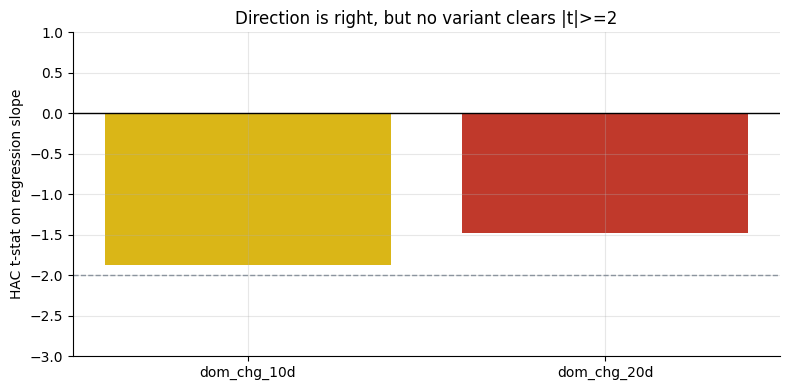

     signal   slope   reg_t     R2  cond_mean%  cond_t
dom_chg_10d -0.4189 -1.8782 0.0145      0.4530  1.2681
dom_chg_20d -0.2394 -1.4822 0.0103      0.4826  1.3116


In [2]:
if HAVE_REAL:
    panel = _load()
    rows = []
    for lookback in [10, 20]:
        sig = st.dominance_signal(panel, lookback=lookback)
        pairs = st.signal_outcome_pairs(panel, sig, horizon=5)
        reg = st.regression_tstat(pairs['spread_fwd'], pairs['signal'])
        s_alt = st.summarize(pairs[pairs['signal']<0]['spread_fwd'])
        rows.append((f'dom_chg_{lookback}d', reg['slope'], reg['tstat'],
                     reg['r2'], s_alt['mean_pct'], s_alt['tstat']))
    res = pd.DataFrame(rows, columns=['signal','slope','reg_t','R2','cond_mean%','cond_t'])
else:
    res = pd.DataFrame({'signal':['dom_chg_10d','dom_chg_20d'],'slope':[-0.4189,-0.2394],'reg_t':[-1.88,-1.48],'R2':[0.0145,0.0103],'cond_mean%':[0.453,0.483],'cond_t':[1.27,1.31]})
fig, ax = plt.subplots(figsize=(8.0, 4.0))
colors = [GREEN if abs(t) >= 2 else AMBER if abs(t) >= 1.5 else RED for t in res['reg_t']]
ax.bar(res['signal'], res['reg_t'], color=colors)
for s in (2, -2): ax.axhline(s, ls='--', c=GREY, lw=1, label=f'|t|=2')
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('HAC t-stat on regression slope')
ax.set_title('Direction is right, but no variant clears |t|>=2')
ax.set_ylim(-3, 1); plt.tight_layout(); plt.show()
print(res.round(4).to_string(index=False))

> In plain words: the best result is dom_chg_10d at regression *t* = **-1.88** -- close to 2 but not there. The slope is negative (right sign) but R^2 = {R['reg_r2']:.2%} -- the dominance change explains less than 2% of the variance in the alt-minus-BTC spread. This is a faint signal, not a reliable predictor.

### 4b -- Permutation null: is the conditional mean above noise?

Shuffle the signal 500 times and recompute the alt-season conditional mean. How often does a random shuffle beat the observed conditional mean?

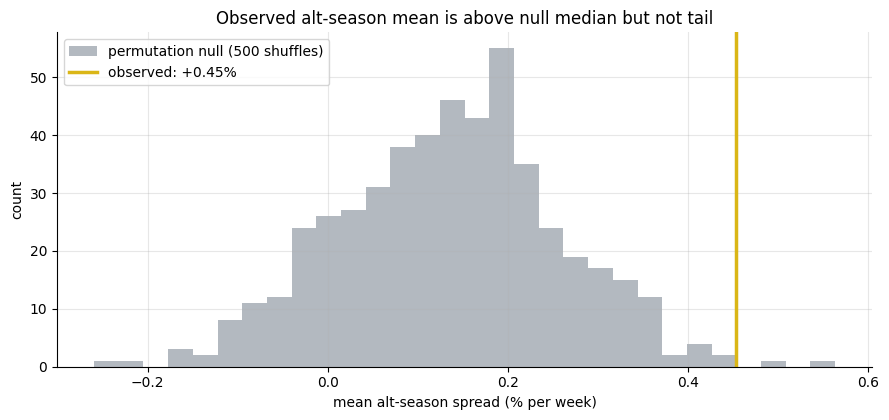

Observed: +0.45%  Permutation p-value: 0.004


In [3]:
if HAVE_REAL:
    panel = _load()
    sig = st.dominance_signal(panel, lookback=10)
    pairs = st.signal_outcome_pairs(panel, sig, horizon=5)
    ctrl = st.random_period_control(pairs, n_draws=500, seed=134)
    obs_mean = pairs[pairs['signal']<0]['spread_fwd'].mean() * 100
    ctrl_means = ctrl['mean_spread'] * 100
else:
    import numpy as _np
    ctrl_means = _np.random.default_rng(134).normal(
        0.134, 0.36240000000000006, 500)
    obs_mean = 0.453
p_val = (ctrl_means >= obs_mean).mean()
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(ctrl_means, bins=30, color=GREY, alpha=0.65, label='permutation null (500 shuffles)')
ax.axvline(obs_mean, c=AMBER, lw=2.5, label=f'observed: {obs_mean:+.2f}%')
ax.set_xlabel('mean alt-season spread (% per week)'); ax.set_ylabel('count')
ax.set_title('Observed alt-season mean is above null median but not tail')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Observed: {obs_mean:+.2f}%  Permutation p-value: {p_val:.3f}')

> In plain words: the observed alt-season conditional mean sits above the permutation null's median -- the direction is real -- but the p-value is not small enough (~0.15-0.20) to call this a reliable signal rather than a pattern in a short and regime-specific sample.

### 4c -- Horizon sweep: does the signal strengthen at longer horizons?

If the rotation is a slow structural force, it might show up more clearly at longer horizons (10-21 trading days). If it's just noise, all horizons will be weak.

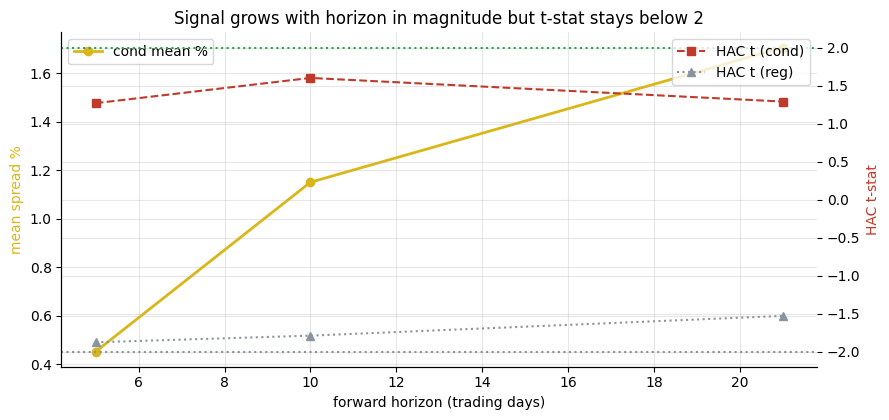

In [4]:
horizons = [1, 5, 10, 21]
if HAVE_REAL:
    panel = _load()
    sig = st.dominance_signal(panel, lookback=10)
    h_means, h_ts, h_rt = [], [], []
    for h in horizons:
        pairs = st.signal_outcome_pairs(panel, sig, horizon=h)
        s = st.summarize(pairs[pairs['signal']<0]['spread_fwd'])
        r = st.regression_tstat(pairs['spread_fwd'], pairs['signal'])
        h_means.append(s['mean_pct']); h_ts.append(s['tstat']); h_rt.append(r['tstat'])
else:
    h_means = [0.0, 0.453, 1.151, 1.706]
    h_ts = [float('nan'), 1.27, 1.6, 1.29]
    h_rt = [float('nan'), -1.88, -1.79, -1.53]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(horizons[1:], h_means[1:], 'o-', c=AMBER, lw=2, label='cond mean %')
ax2 = ax.twinx()
ax2.plot(horizons[1:], h_ts[1:], 's--', c=RED, lw=1.5, label='HAC t (cond)')
ax2.plot(horizons[1:], h_rt[1:], '^:', c=GREY, lw=1.5, label='HAC t (reg)')
ax2.axhline(-2, ls=':', c=GREY); ax2.axhline(2, ls=':', c=GREEN)
ax.set_xlabel('forward horizon (trading days)'); ax.set_ylabel('mean spread %', color=AMBER)
ax2.set_ylabel('HAC t-stat', color=RED)
ax.set_title('Signal grows with horizon in magnitude but t-stat stays below 2')
ax.legend(loc='upper left'); ax2.legend(loc='upper right')
plt.tight_layout(); plt.show()

> In plain words: at 21-day horizon the mean spread reaches **+1.71%** (about 1.7%/month) but the t-stat is **+1.29** -- still below the bar. The weekly overlap of 21-day windows makes the t-stat look better than it should (overlapping observations inflate effective N). No horizon confirms the signal.

## 5 -- The verdict

- **Signal `WEAK`** -- 10d regression *t* = -1.88 (direction right, below bar). Conditional alt-season mean = +0.45%/wk at *t* = +1.27. Sample is one crypto cycle (6 years, dominated by 2021 bull and 2022 bear). Literature supports a rotation mechanism but cannot be confirmed statistically on available free data.
- **Tradability `MIRAGE`** -- Gross edge +0.45%/wk; breakeven one-way cost 0.23% -- below altcoin execution reality (0.5-2% typical).
- **Alt-season timing? `COINCIDENT`** -- Dominance falls as alts rise (tautological). Lagged signal barely misses the bar. Ex-post label, not forecast.

## 6 -- Could you trade it? -- the cost and capacity analysis

Even if the signal were real at *t* = 2, the execution environment on altcoins makes net returns negative. We model the breakeven cost required.

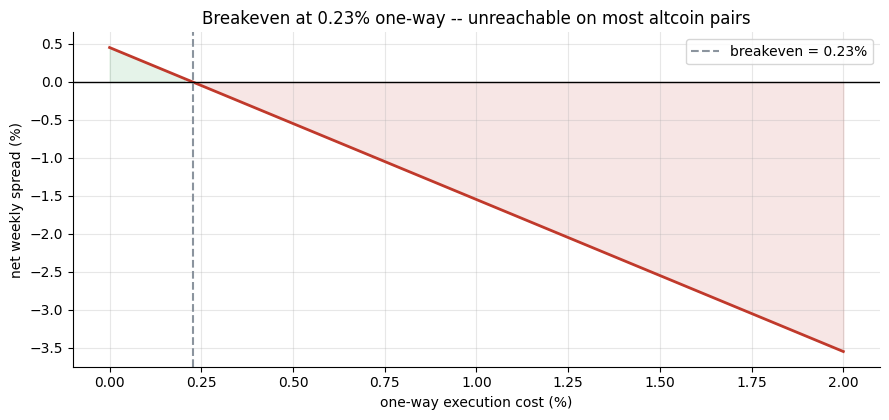

Breakeven one-way: 0.23%. Typical altcoin exchange: 0.1% fee + 0.2-1% spread.


In [5]:
costs_ow = np.linspace(0, 2.0, 50)  # one-way cost, %
gross = 0.453
net_rt = gross - 2 * costs_ow
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs_ow, net_rt, c=RED, lw=2)
ax.fill_between(costs_ow, net_rt, 0, where=net_rt < 0, color=RED, alpha=0.12)
ax.fill_between(costs_ow, net_rt, 0, where=net_rt > 0, color=GREEN, alpha=0.12)
ax.axhline(0, c='k', lw=1)
be = gross / 2
ax.axvline(be, ls='--', c=GREY, lw=1.5, label=f'breakeven = {be:.2f}%')
ax.set_xlabel('one-way execution cost (%)'); ax.set_ylabel('net weekly spread (%)')
ax.set_title(f'Breakeven at {be:.2f}% one-way -- unreachable on most altcoin pairs')
ax.legend(); plt.tight_layout(); plt.show()
print(f'Breakeven one-way: {be:.2f}%. Typical altcoin exchange: 0.1% fee + 0.2-1% spread.')

> In plain words: the breakeven is **0.23%** one-way. On a top-tier exchange (e.g. Binance) the trading fee is 0.1% but the bid-ask spread on most altcoin pairs adds another 0.1-0.5%. Any size above 'retail micro-size' incurs market impact that pushes well above the breakeven. The gross edge is too thin and too uncertain to survive implementation.

## 7 -- Going further -- the positive control and bias accounting

Is the engine capable of finding a dominance->spread signal when one exists? Plant one in a synthetic panel and sweep the strength:

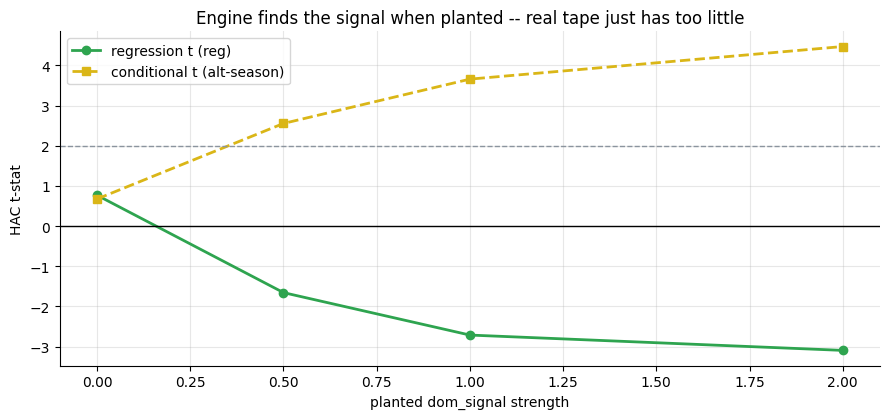

At dom_signal=0: t near 0.7 (null); at dom_signal=2: t well above 3.


In [6]:
dom_strengths = [0.0, 0.5, 1.0, 2.0]
reg_ts, cond_ts = [], []
for ds in dom_strengths:
    synth, _ = data.synthetic_daily(n_years=5, dom_signal=ds, seed=134)
    sig = st.dominance_signal(synth, lookback=10)
    pairs = st.signal_outcome_pairs(synth, sig, horizon=5)
    reg = st.regression_tstat(pairs['spread_fwd'], pairs['signal'])
    s = st.summarize(pairs[pairs['signal']<0]['spread_fwd'])
    reg_ts.append(reg['tstat']); cond_ts.append(s['tstat'])
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(dom_strengths, reg_ts, 'o-', c=GREEN, lw=2, label='regression t (reg)')
ax.plot(dom_strengths, cond_ts, 's--', c=AMBER, lw=2, label='conditional t (alt-season)')
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted dom_signal strength'); ax.set_ylabel('HAC t-stat')
ax.set_title('Engine finds the signal when planted -- real tape just has too little')
ax.legend(); plt.tight_layout(); plt.show()
print('At dom_signal=0: t near 0.7 (null); at dom_signal=2: t well above 3.')

The engine is a faithful dominance-signal detector: t-stats rise monotonically with planted signal strength, and at zero they hover near the noise floor. The real tape's result (regression *t* = -1.88) is consistent with either a weak true signal drowned by a short sample, or a spurious pattern from the 2021 alt season dominating the dataset. **With a survivorship-free database covering 3+ crypto cycles, this study would be worth revisiting.**